In [14]:
from datetime import datetime
import numpy as np
import pandas as pd
import pyarrow

from investment_lab.data.option_db import OptionLoader, AAPLOptionLoader, extract_spot_from_options
from investment_lab.option_trade import DeltaHedgedOptionTrade, OptionTrade
from investment_lab.option_strategies import SHORT_1W_STRADDLE
from investment_lab.backtest import BacktesterBidAskFromData
from investment_lab.stochastic.heston_ssm import HestonParams, HestonStateSpaceModel
from investment_lab.stochastic.ukf import ScalarUnscentedKalmanFilter
from investment_lab.stochastic.heston_mle import fit_heston_params_rolling
from investment_lab.allocation import compute_linear_weights, rescale_positions_with_signal
from investment_lab.metrics.performance import format_perf_table
from investment_lab.plots import plot_results

In [15]:
START = datetime(2020, 1, 2)
END = datetime(2022, 12, 30)
TICKER = "SPY"
df_options  = OptionLoader.load_data(start_date=START, end_date=END, process_kwargs={"ticker": TICKER})

In [13]:
TICKER = "AAPL"
#START = datetime(2016, 1, 4)
#END = datetime(2023, 3, 31)
START = datetime(2020, 1, 2)
END = datetime(2022, 12, 30)
df_options = AAPLOptionLoader.load_data(start_date=START, end_date=END, process_kwargs={"ticker": TICKER})

In [16]:
df_spot = extract_spot_from_options(df_options).set_index("date")["spot"]
log_returns = np.log(df_spot / df_spot.shift(1)).dropna()

In [17]:
WINDOW        = 63
RECALIB_EVERY = 21

r  = log_returns.values
kf = ScalarUnscentedKalmanFilter()

filtered_var   = np.full(len(r), np.nan)
current_params = None

for t in range(len(r)):
    if t >= WINDOW and t % RECALIB_EVERY == 0:
        fit = fit_heston_params_rolling(r[t - WINDOW: t], min_obs=WINDOW, ukf=kf)
        if fit.success:
            current_params = fit.params
    if current_params is not None:
        model  = HestonStateSpaceModel(current_params)
        result = kf.filter(
            r[max(0, t - WINDOW): t + 1],
            model=model,
            init_state=current_params.theta,
            init_var=0.01,
        )
        filtered_var[t] = result.filtered_state[-1]

sigma_filtered = pd.Series(
    np.sqrt(np.maximum(filtered_var, 0.0)),
    index=log_returns.index,
    name="sigma_filtered",
).dropna()

# Pour rester compatible avec la cellule 6 qui utilise kalman_result["sigma_filtered"]
kalman_result = pd.DataFrame({"sigma_filtered": sigma_filtered})

In [25]:
# UKF + rolling MLE calibration with the new SSM/UKF
ukf = ScalarUnscentedKalmanFilter()
window = 63
recalib_every = 21

r = log_returns.values
n = len(r)

# Init from short window variance (annualized)
init_state = float(np.var(r[:min(21, n)]) * 252)
init_var = 1e-3
m_prev, p_prev = init_state, init_var

params = HestonParams(kappa=2.0, theta=0.04, xi=0.30, rho=-0.5, mu=0.0)
model = HestonStateSpaceModel(params)

v_filt = np.zeros(n)
v_var = np.zeros(n)
kappas = np.zeros(n)
thetas = np.zeros(n)
xis = np.zeros(n)
rhos = np.zeros(n)
mus = np.zeros(n)

for t in range(n):
    if t >= window and t % recalib_every == 0:
        fit = fit_heston_params_rolling(r[t - window: t], ukf=ukf)
        params = fit.params
        model = HestonStateSpaceModel(params)

    res = ukf.filter([r[t]], model=model, init_state=m_prev, init_var=p_prev, measurement_var=1e-8)
    m_prev = float(res.filtered_state[-1])
    p_prev = float(res.filtered_var[-1])

    v_filt[t] = m_prev
    v_var[t] = p_prev
    kappas[t] = params.kappa
    thetas[t] = params.theta
    xis[t] = params.xi
    rhos[t] = params.rho
    mus[t] = params.mu

kalman_result = pd.DataFrame(
    {
        "v_filtered": v_filt,
        "sigma_filtered": np.sqrt(np.maximum(v_filt, 0.0)),
        "log_return": r,
        "kappa": kappas,
        "theta": thetas,
        "xi": xis,
        "rho": rhos,
        "mu": mus,
    },
    index=log_returns.index,
)


In [26]:
df_positions_static = DeltaHedgedOptionTrade.generate_trades(
    start_date=START, end_date=END, tickers=[TICKER], legs=SHORT_1W_STRADDLE,
)
df_positions_static_without_delta = OptionTrade.generate_trades(
    start_date=START, end_date=END, tickers=[TICKER], legs=SHORT_1W_STRADDLE,
)

In [33]:
r = log_returns.values
fit = fit_heston_params_rolling(r, min_obs=63)
print("Paramètres calibrés:", fit.params)

# Filtrage avec les paramètres calibrés
model = HestonStateSpaceModel(fit.params)
kf = ScalarUnscentedKalmanFilter()
result = kf.filter(r, model=model, init_state=fit.params.theta, init_var=0.01)

sigma_filtered = pd.Series(
    np.sqrt(result.filtered_state),  # variance -> volatilité
    index=log_returns.index,
    name="sigma_filtered",
)

# Spread et suite du pipeline inchangés
spread = (
    atm_iv
    .sub(sigma_filtered)
    .shift(1)
    .dropna()
    .rename("iv_rv_spread")
)

dynamic_weights = compute_linear_weights(spread, w_min=0.0, w_max=1.0, window=63)
df_positions_dynamic = rescale_positions_with_signal(df_positions_static, dynamic_weights)
backtester_dynamic = BacktesterBidAskFromData(df_positions_dynamic).compute_backtest()

print(format_perf_table({
    "Static": backtester_static.nav,
    "Dynamic (UKF MLE)": backtester_dynamic.nav,
}))

Paramètres calibrés: HestonParams(kappa=np.float64(1.585833874684997), theta=np.float64(0.11516503989580941), xi=np.float64(1.2715683426858329), rho=np.float64(-0.5), mu=np.float64(-0.34160287007480133))


100%|██████████| 774/774 [00:10<00:00, 71.93it/s]


             Static Dynamic (UKF MLE)
Ann. Return   2.43%             1.54%
Ann. Vol      6.20%             3.02%
Sharpe        0.392             0.509
Max DD       -9.05%            -4.19%
Calmar        0.269             0.367


In [27]:
atm_iv = (
    df_options[df_options["call_put"] == "C"]
    .assign(dist=lambda d: (d["moneyness"] - 1).abs())
    .loc[lambda d: d.groupby("date")["dist"].transform("min") == d["dist"]]
    .groupby("date")["implied_volatility"]
    .first()
)

spread = (
    atm_iv
    .sub(kalman_result["sigma_filtered"])
    .shift(1)           
    .dropna()
    .rename("iv_rv_spread")
)

In [28]:
dynamic_weights = compute_linear_weights(spread, w_min=0.0, w_max=1.0, window=63)

In [29]:
df_positions_dynamic = rescale_positions_with_signal(df_positions_static, dynamic_weights)
df_positions_dynamic_without_delta = rescale_positions_with_signal(df_positions_static_without_delta, dynamic_weights)

In [30]:
backtester_static  = BacktesterBidAskFromData(df_positions_static).compute_backtest()
backtester_static_wo_delta  = BacktesterBidAskFromData(df_positions_static_without_delta).compute_backtest()
backtester_dynamic = BacktesterBidAskFromData(df_positions_dynamic).compute_backtest()
backtester_dynamic_wo_delta = BacktesterBidAskFromData(df_positions_dynamic_without_delta).compute_backtest()

100%|██████████| 774/774 [00:06<00:00, 115.47it/s]


In [31]:
print(format_perf_table({
    "Static (delta-hedged carry)": backtester_static.nav,
    "Dynamic (UKF spread signal)": backtester_dynamic.nav,
}))
print(format_perf_table({
    "Static w.o. delta hedging ": backtester_static_wo_delta.nav,
    "Dynamic w.o. delta hedging ": backtester_dynamic_wo_delta.nav,
}))


            Static (delta-hedged carry) Dynamic (UKF spread signal)
Ann. Return                       2.43%                       0.50%
Ann. Vol                          6.20%                       2.79%
Sharpe                            0.392                       0.180
Max DD                           -9.05%                      -5.44%
Calmar                            0.269                       0.092
            Static w.o. delta hedging  Dynamic w.o. delta hedging 
Ann. Return                      2.51%                       0.44%
Ann. Vol                         7.45%                       3.01%
Sharpe                           0.337                       0.148
Max DD                          -8.42%                      -5.71%
Calmar                           0.298                       0.078


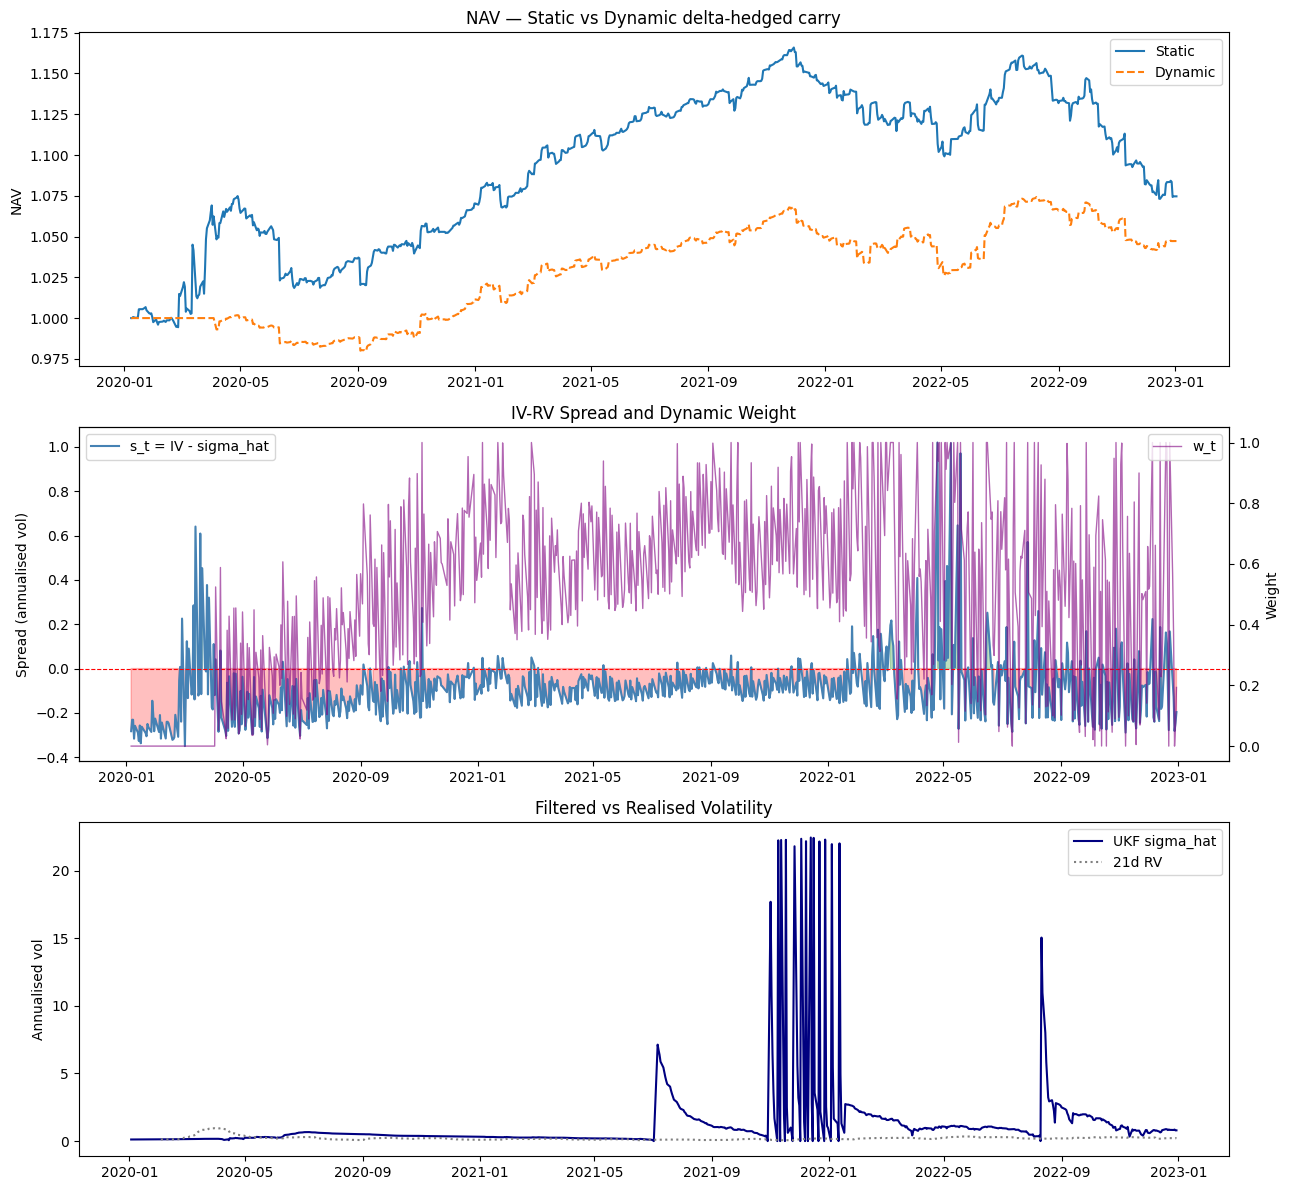

In [34]:
plot_results(
    backtester_static=backtester_static,
    backtester_dynamic=backtester_dynamic,
    spread=spread,
    dynamic_weights=dynamic_weights,
    sigma_filtered=kalman_result["sigma_filtered"],
    log_returns=log_returns,
)